# 大语言模型基础

PS: 语义分析, 从简单的编码(eg. unicode)到能承载语义信息的编码(eg. embedding)
, 附以处理机制
## lm的发展

lm的**根本任务**是计算一个词序列出现的概率, 是agent理解指令的基础

### 统计语言模型

PS: 在dl出现之前

统计方法, 一个句子出现的概率, 是其中每个词出现条件概率的连乘
$$
P(S) = P(w_1, w_2, \dots, w_m) = P(w_1) \cdot P(w_2 \mid w_1) \cdot P(w_3 \mid w_1, w_2) \cdots P(w_m \mid w_1, \dots, w_{m-1})
$$

**问题**:
- 上下文太长
- 条件概率如何计算

#### 上下文太长
引入马尔可夫假设, 使用长度为 N 的上下文窗口, 

例如, N=3时
$$
P(w_i \mid w_1, \dots, w_{i-1}) \approx P(w_i \mid w_{i-2}, w_{i-1})
$$

要不要我帮你把这些公式整理成一个**可直接复制的LaTeX代码块**，方便你在论文或笔记里使用？

#### 条件概率如何计算
使用最大似然估计的思想: 出现概率大, 代表出现的次数多. 使用出现的次数来代替出现的概率

$$
P(w_i \mid w_{i-1}) = \frac{Count(w_{i-1}, w_i)}{Count(w_{i-1})}
$$

**致命缺陷**
PS: 数据是一个又一个的孤立点
- 数据稀疏
- 泛化能力差: 无法处理语义信息, 只是简单词频计算

### 神经网络: 解决了泛化能力差

`FFNN LM` 是一个里程碑, 其中引入词嵌入的思想, 展现出一定的语义信息(embedding做到了既能数字化又可以承载语义)

### RNN和LSTM: 解决了上下文有限的问题

LSTM 是一种特殊的 RNN

**致命问题**
- 顺序进行, 无法并行计算, 效率低

## 里程碑: transformer
PS: 完全抛弃循环结构, 使用注意力机制

### 基本原理

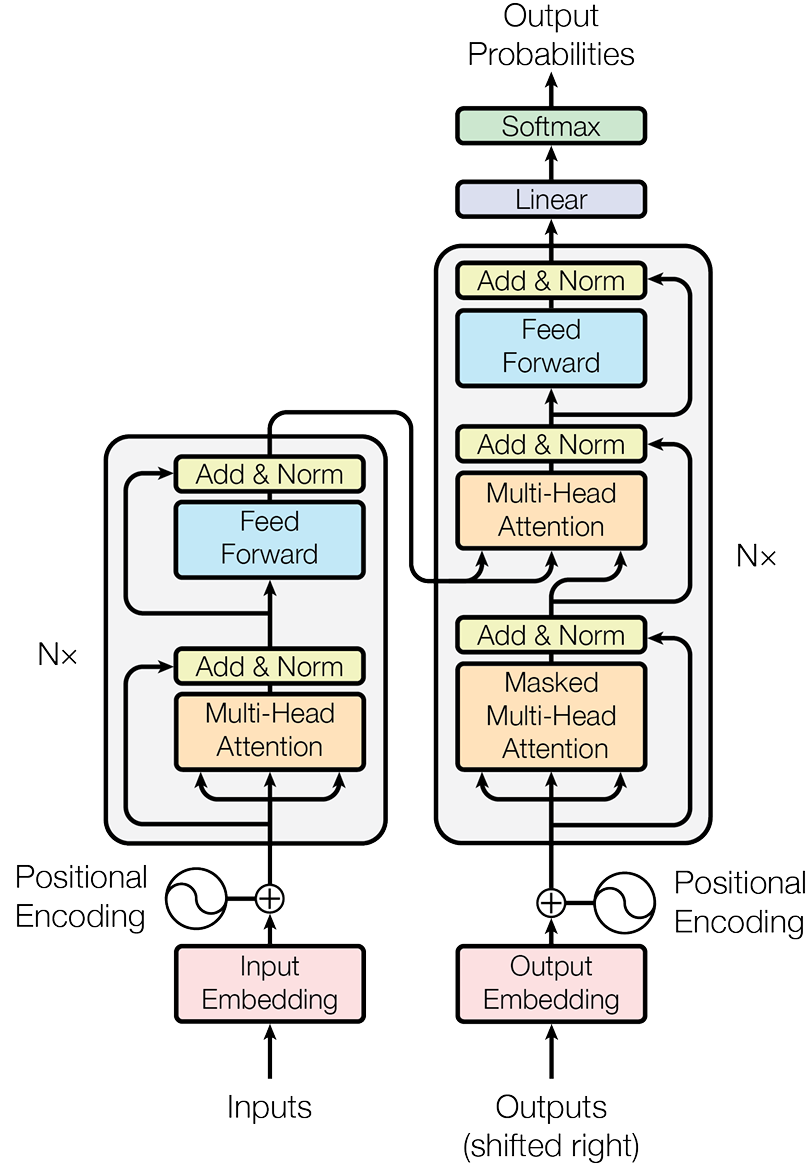

[Transformer是什么？2017年那篇“无人问津”的论文，为何成了今天AI爆炸的起点？10分钟速通AI论文天花板《Attention is all you](https://www.bilibili.com/video/BV1G4iMBeEWH/?share_source=copy_web&vd_source=041c00ce3c624a152104cf7a27622a71)


#### record

##### embedding
- 文本 -> 数字: embedding, 使用向量承载**语义信息**
- 文本+位置 -> 数字: 上述的基础上加入**位置信息**
##### multi-attention

模型在处理序列中的每一个词时，都能兼顾序列中的**所有其他词**, 并为这些词分配不同的“注意力权重”

PS: 是因为考虑到自然语言中, 每个词的语义都是多样的. 所以使用**当前词+其他词(语境)**来具体化(表示)当前词吗

划重点: 原向量 -> QKV(query, key, value) -> 多头(切分方法很多, 切分后维度一般降低) -> 合并 -> 新向量

上面提到, 由原始语义已经得到一个向量.

然后分别乘以三个可学习的矩阵 $W^Q$, $W^K$, $W^V$, 得到三个新的向量 $Q, K, V$

PS: 一个人三个身份参与到注意力机制中

进行一系列处理, 如公式, 得到一个词的新的表示, 其他词元同样

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

##### ff

提取更高阶的特征

##### add & norm

解决梯度消失问题, 同时提高模型训练的稳定性

##### position-encode

数学公式计算得到

## decode-only

相比完整的transformer, 抛弃了encode, 只保留decode, 即decode-only, 这种工作模型是自回归

eg.
- 给一个初始文本. I love
- 预测下一个词. you
- 刚预测的词+初始文本. I love you
- 再预测下一个词. .
- 循环往复, 直到终止. I love you.

# 使用llm

## prompt

PS: people和llm沟通的桥梁是**prompt**, prompt工程就是研究如何设计出精准的提示, 从而引导模型产生准确的输出(符合人的意愿的)

### temperature

通过改变`softmax`处的公式, 来改变

PS: softmax负责把一组实数变为概率分布( 在[0,1]之间 ), 公式如下

$$
p(i \mid T) = \frac{e^{z_i/T}}{\sum_{j=1}^k e^{z_j/T}}
$$

T变小, 分布函数更陡峭; T变大, 分布函数更平坦, 输出更多样

PS: 下面是temperature确定概率函数后, 对token的输出选取方式. top-k和top-p

### top-k

按照 softmax 的输出, 筛选出前k个概率最高的token. 重新计算概率, 然后采样

top-k越小, 输出约保守; top-k约大, 输出越多样

### top-p

按照 softmax 的输出, 从token概率最高的向着最低的叠加, 直到达到阈值; 然后重新计算概率, 采样

PS: 很类似于cp那种概率保证

PS: top-k和top-p可以二者兼用, 也可以只用其一

### instruction tuning

按照上面的思路看下来, llm只是在做文本的生成工作, 指令遵循上会比较差. 

使用大量“指令-回答”格式的数据对预训练模型进行进一步的训练, 让人与llm的交互更加的流畅

### cot

chain of thought: 显式的推理, 输出准确性更高

## 文本分词: tokenization

PS: 将原始文本切为`token`

有很多分词算法
- 考虑泛化性
- 能进行迭代

理解分词很很重要, 因为他决定了你这一句话有多少token

> 有时模型的奇怪表现根源在于分词。例如，模型可能很擅长计算 2 + 2，但对于 2+2（没有空格）就可能出错，因为后者可能被分词器视为一个独立的、不常见的词元。同样，一个词因为首字母大小写不同，也可能被切分成完全不同的 Token 序列，从而影响模型的理解。在设计提示词和解析模型输出时，考虑到这些“陷阱”有助于提升智能体的鲁棒性。

# llm的特点

## 缩放法则

模型的**性能**和**模型参量**、**模型数据量**、**计算资源**之间存在明显的幂律关系,

即只要按比例增加上述三个参数, 模型的性能就可以平滑的上升, 而不会遇到明显的瓶颈

## 涌现能力

随着模型参数的增大, 会出现小模型中不存在的能力

比如, 链式思考, 指令遵循, 代码生成等

## 幻觉

大体分为两类
- 完全自行捏造
- 与客观事实, 用户输入, 上下文信息矛盾



# 统计方法

In [1]:
import collections

In [2]:
corpus = "datawhale agent learns datawhale agent works"
# 计算 P(datawhale, agent, learns), N=2
corpus

'datawhale agent learns datawhale agent works'

In [3]:
tokens = corpus.split()
tokens

['datawhale', 'agent', 'learns', 'datawhale', 'agent', 'works']

In [4]:
bigrams = list(zip(tokens, tokens[1:]))
# for i in bigrams:
    # print(i)
bigrams

[('datawhale', 'agent'),
 ('agent', 'learns'),
 ('learns', 'datawhale'),
 ('datawhale', 'agent'),
 ('agent', 'works')]

In [5]:
bigrams_counter = collections.Counter(bigrams)
for i in bigrams_counter:
    print(i)
    print(bigrams_counter[i])


('datawhale', 'agent')
2
('agent', 'learns')
1
('learns', 'datawhale')
1
('agent', 'works')
1


In [6]:
p_datawhale_all = tokens.count("datawhale") / len(tokens)
p_datawhale_all

0.3333333333333333

In [7]:
p_agent_datawhale = bigrams_counter[('datawhale', 'agent')] / tokens.count('datawhale')
p_agent_datawhale

1.0

In [8]:
p_learn_agent = bigrams_counter['agent', 'learns'] / tokens.count('agent')
p_learn_agent

0.5

In [9]:
p = p_datawhale_all * p_agent_datawhale * p_learn_agent
p

0.16666666666666666

# FFNN

In [10]:
%cd ../
import os
os.getcwd()

/Users/yqz/project/hello-agents


'/Users/yqz/project/hello-agents'

In [11]:
# api
from openai import OpenAI
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import pandas as pd
import numpy as np

def compute_similarity_qwen(texts, api_key="sk-44f5ffcb3d274162aa0c42ac2e7bfbb4", 
                            model="text-embedding-v4", dimensions=3072):
    """
    使用阿里云百炼(qwen)计算文本列表之间的欧氏距离和余弦相似度
    
    Args:
        texts: 文本列表，如 ["text1", "text2", "text3"]
        api_key: 阿里云API密钥
        model: embedding模型名称
        dimensions: 向量维度
    
    Returns:
        sim_df: 余弦相似度 DataFrame
        dist_df: 欧氏距离 DataFrame
    """
    # 获取 embedding
    client = OpenAI(
        api_key=api_key,
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
    )
    response = client.embeddings.create(
        model=model,
        input=texts,
        dimensions=dimensions,
        encoding_format="float"
    )
    
    # 提取向量并转为矩阵
    embeddings = np.array([data.embedding for data in response.data])
    
    # 计算相似度和距离
    sim_matrix = cosine_similarity(embeddings)
    dist_matrix = euclidean_distances(embeddings)
    
    # 转为 DataFrame，用原始文本作为索引
    sim_df = pd.DataFrame(sim_matrix, index=texts, columns=texts).round(4)
    dist_df = pd.DataFrame(dist_matrix, index=texts, columns=texts).round(4)
    
    return sim_df, dist_df


In [12]:
texts = [
    "I love you",
    "I hate you",
    "You are the best"
]

In [13]:
compute_similarity_qwen(texts=texts)

(                  I love you  I hate you  You are the best
 I love you            1.0000      0.6052            0.4694
 I hate you            0.6052      1.0000            0.4310
 You are the best      0.4694      0.4310            1.0000,
                   I love you  I hate you  You are the best
 I love you            0.0000      0.8886            1.0302
 I hate you            0.8886      0.0000            1.0667
 You are the best      1.0302      1.0667            0.0000)

# tranformer

以后有空再写

<img src="https://raw.githubusercontent.com/datawhalechina/Hello-Agents/main/docs/images/3-figures/1757249275674-3.png" alt="图片描述" style="zoom:40%;" />

里面的基本模块
- PositionEncoding
- MultiHeadAttention: Masked简单
- FeedForward
- Add & Norm: 这个比较简单


In [14]:
import torch
import torch.nn as nn
import math

In [15]:
class PositionEncoding(nn.Module):
    def forward(self, x):
        pass

In [16]:
class MutliHeadAttention(nn.Module):
    def forward(self, query, key, value, mask):
        pass

In [17]:
class FeedForward(nn.Module):
    def forward(self, x):
        pass

In [19]:
# 解码核心逻辑
class EncoderLayter(nn.Module):
    pass

# local large language model

In [87]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [88]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device


'mps'

In [89]:
# 模型配置
model_id = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [113]:
# 输入设置
messages = [
    {
        "role":"system", "content":"You are a helpful assitant",
        "role":"user"  , "content":"who are you",
    }
]
print(f"原始的messages: \n{messages}\n")

messages_format = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True
)
print(f"格式化后的messages: \n{messages_format}\n")

input_id = tokenizer(
    messages_format,
    return_tensors='pt'
).to(device)
print(f"向量化后的: \n{input_id}\n")

原始的messages: 
[{'role': 'user', 'content': 'who are you'}]

格式化后的messages: 
<|im_start|>user
who are you<|im_end|>
<|im_start|>assistant


向量化后的: 
{'input_ids': tensor([[151644,    872,    198,  14623,    525,    498, 151645,    198, 151644,
          77091,    198]], device='mps:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='mps:0')}



In [ ]:
# 模型处理
# 这里一定要加 max_new_tokens, 默认的是20, 但是后续会移除应该. 
output_id = model.generate(
    input_id.input_ids,
    max_new_tokens=512
)
print(f"模型输出: \n{output_id}\n")

模型输出: 
tensor([[151644,    872,    198,  14623,    525,    498, 151645,    198, 151644,
          77091,    198, 151667,    198,  32313,     11,    279,   1196,   4588,
             11,    330,  15191,    525,    498,   7521,   2055,    358,   1184,
            311,   5889,    304,    264,  11657,    323,  10950,   1616,     13,
           6771,    752,   1191,    553,  60608,    862,   3405,     13,    358,
           1265,   6286,    429,    358,   2776,    264,   4128,   1614,     11,
            714,    358,    646,   3061,    311,   1105,    304,    894,   4128,
            807,   1366,     13,   1084,    594,   2989,    311,   2506,    279,
           2033,   6785,    323,   1787,  83075,    311,  14907,   4623,  10435,
             13,    358,   1265,   1083,   3010,  12994,    304,   1142,    807,
            614,    803,   4755,     13,   6771,    752,   1281,   2704,    279,
          16232,    374,   5810,    323,    537,   2238,  15908,     13,  97593,
             11,  106

In [115]:
# 解析模型输出: 先给你看看初始内容
tokenizer.batch_decode(
    output_id,
)

['<|im_start|>user\nwho are you<|im_end|>\n<|im_start|>assistant\n<think>\nOkay, the user asked, "Who are you?" So I need to respond in a friendly and helpful way. Let me start by acknowledging their question. I should mention that I\'m a language model, but I can talk to them in any language they want. It\'s important to keep the response positive and open-ended to encourage further conversation. I should also offer assistance in case they have more questions. Let me make sure the tone is natural and not too formal. Alright, putting it all together in a conversational way.\n</think>\n\nI\'m a language model, but I can speak any language you want! What\'s interesting about you? Do you have questions? Let me know how I can help! 😊<|im_end|>']

In [116]:
# 解析模型输出, 去掉开始的输入内容
generate_id = [output[len(input):] for output, input in zip(output_id, input_id)]
print(f"去除输入后的输出: {generate_id}")

generate = tokenizer.batch_decode(
    generate_id,
    skip_special_token=True
)
print(f"解析后的输出: {generate}")

去除输入后的输出: [tensor([ 77091,    198, 151667,    198,  32313,     11,    279,   1196,   4588,
            11,    330,  15191,    525,    498,   7521,   2055,    358,   1184,
           311,   5889,    304,    264,  11657,    323,  10950,   1616,     13,
          6771,    752,   1191,    553,  60608,    862,   3405,     13,    358,
          1265,   6286,    429,    358,   2776,    264,   4128,   1614,     11,
           714,    358,    646,   3061,    311,   1105,    304,    894,   4128,
           807,   1366,     13,   1084,    594,   2989,    311,   2506,    279,
          2033,   6785,    323,   1787,  83075,    311,  14907,   4623,  10435,
            13,    358,   1265,   1083,   3010,  12994,    304,   1142,    807,
           614,    803,   4755,     13,   6771,    752,   1281,   2704,    279,
         16232,    374,   5810,    323,    537,   2238,  15908,     13,  97593,
            11,  10687,    432,    678,   3786,    304,    264,   7517,   1663,
          1616,    624, 15166